In [9]:
import torch
import torch.nn as nn
from torchvision import transforms,datasets
from torch.utils.data import dataloader
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(
        32,4
    ),transforms.ToTensor()]
)
test_transforms = transforms.ToTensor()
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    transform=train_transforms,
    download=False
)
train_loader = dataloader.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    transform=test_transforms,
    download=False
)
test_loader = dataloader.DataLoader(
    test_dataset,
    batch_size=256
)

In [11]:
model = nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32,32,3,padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Conv2d(32,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Conv2d(64,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(8*8*64,128),
    nn.ReLU(),
    
    nn.Linear(128,64),
    nn.ReLU(),
    
    nn.Linear(64,10),
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

device = torch.device("cuda")
model = model.to(device)

AttributeError: module 'torch' has no attribute '_utils'

In [ ]:
for epoch in range(25):
    correct = 0
    total = 0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output,labels)
        output = output.argmax(dim=1)
        correct += (output==labels).sum().item()
        loss.backward()
        optimizer.step()
        total += labels.size(0)
    print(f"Training Accuracy :{(correct/total * 100)}")


Training Accuracy :46.304
Training Accuracy :62.117999999999995
Training Accuracy :67.12
Training Accuracy :70.03200000000001
Training Accuracy :72.206
Training Accuracy :73.77
Training Accuracy :74.846
Training Accuracy :76.198
Training Accuracy :77.25
Training Accuracy :78.01
Training Accuracy :78.694
Training Accuracy :79.366
Training Accuracy :80.214
Training Accuracy :80.638
Training Accuracy :80.64
Training Accuracy :81.30199999999999
Training Accuracy :81.604
Training Accuracy :82.344
Training Accuracy :82.694
Training Accuracy :82.958
Training Accuracy :83.196
Training Accuracy :83.77
Training Accuracy :83.828
Training Accuracy :84.352
Training Accuracy :84.398


: 

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        output = output.argmax(dim=1)
        correct += (output==labels).sum().item()
        total += labels.size(0)
print(f"Testing Accuracy :{correct/total*100}")

Testing Accuracy :80.35


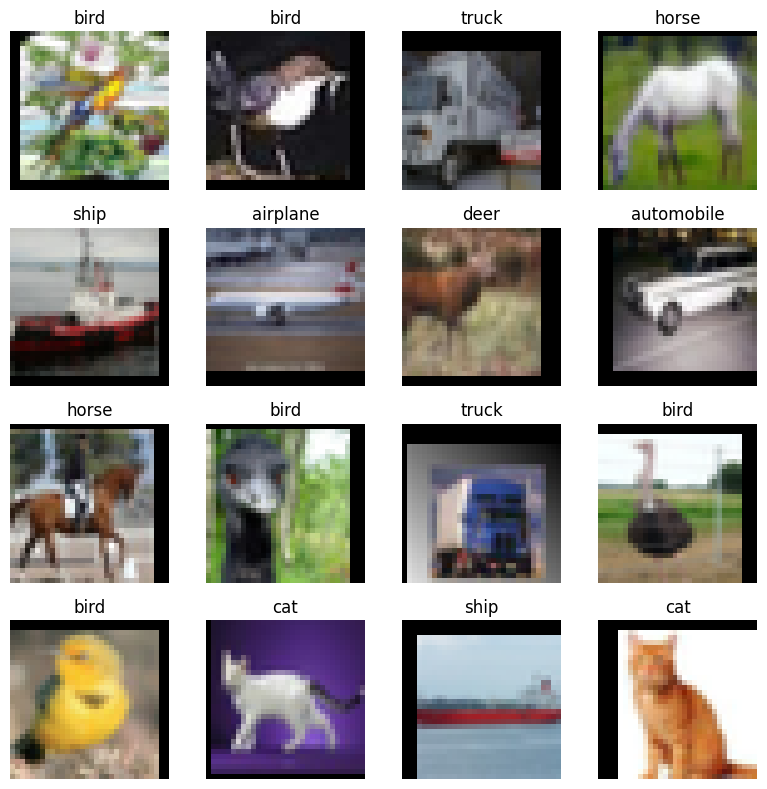

In [ ]:
import matplotlib.pyplot as plt
import random

classes = train_dataset.classes

plt.figure(figsize=(8,8))

for i in range(16):

    idx = random.randint(
        0,
        len(train_dataset)-1
    )

    image,label = train_dataset[idx]

    plt.subplot(4,4,i+1)

    plt.imshow(
        image.permute(1,2,0)
    )

    plt.title(
        classes[label]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from resNet import CNN
model = CNN()
device = torch.device("cuda")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

for epoch in range(25):
    correct = 0
    model.train()
    total = 0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optim.zero_grad()
        output = model(images)
        loss = criterion(output,labels)
        output = output.argmax(dim=1)
        correct += (output==labels).sum().item()
        loss.backward()
        optim.step()
        total += labels.size(0)
    print(f"Training Accuracy :{(correct/total * 100)}")


AttributeError: module 'torch' has no attribute '_utils'

In [ ]:
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        out = out.argmax(dim=1)
        correct += (out==labels).sum().item()
        total += labels.size(0)
    print(f"Test Accuracy:{correct/total*100}")

Test Accuracy:84.11


In [16]:
import torch
print(torch.__version__)
print(torch.__file__)

2.12.1+cu130
d:\Program Files\Python\Lib\site-packages\torch\__init__.py
